<a href="https://colab.research.google.com/github/asmita-durugkar/ml_learning/blob/main/pumpkin_price_analysis_lr_polynomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

url='https://raw.githubusercontent.com/microsoft/ML-For-Beginners/refs/heads/main/2-Regression/data/US-pumpkins.csv'
df = pd.read_csv(url)
df.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [3]:
df.isnull().sum()
selected_coulmns=['Package','Low Price','High Price','Date']
df=df.loc[:,selected_coulmns]
df


,Package,Low Price,High Price,Date
0,24 inch bins,270.00,280.00,4/29/17
1,24 inch bins,270.00,280.00,5/6/17
2,24 inch bins,160.00,160.00,9/24/16
3,24 inch bins,160.00,160.00,9/24/16
4,24 inch bins,90.00,100.00,11/5/16
...,...,...,...,...
1752,22 lb cartons,14.75,14.75,9/30/16
1753,36 inch bins,275.00,275.00,9/26/16
1754,36 inch bins,275.00,275.00,9/27/16
1755,36 inch bins,275.00,275.00,9/28/16


In [4]:
# 1. Filter out the bins/boxes immediately into a new dataframe
price_lb = df[df['Package'].str.contains('lb', case=False, na=False)].copy()

# 2. Calculate the average price and extract the month strictly using the filtered rows
price_for_lb = (price_lb['Low Price'] + price_lb['High Price']) / 2
month_for_lb = pd.DatetimeIndex(price_lb['Date']).month

# 3. Extract the numeric values from the package text (e.g., "22" from "22 lb cartons")
price_lb['wt_lbs'] = price_lb['Package'].str.extract(r'(\d+)').astype(float)

# 4. Convert pounds to Kilograms
price_lb['wt_kgs'] = price_lb['wt_lbs'] * 0.453592

# 5. Calculate price per kg using the matching filtered lengths
price_lb['price_per_kg'] = price_for_lb / price_lb['wt_kgs']

# 6. Build your final clean dataframe using only the filtered data sources
new_df = pd.DataFrame({
    'Month': month_for_lb,
    'Package': price_lb['Package'],
    'Low Price': price_lb['Low Price'],
    'High Price': price_lb['High Price'],
    'Price per kg': price_lb['price_per_kg'],
    'weight_kg': price_lb['wt_kgs']
})

# Display the clean dataframe
new_df

,Month,Package,Low Price,High Price,Price per kg,weight_kg
45,8,50 lb sacks,29.00,29.00,1.278682,22.679600
46,8,50 lb sacks,29.00,29.00,1.278682,22.679600
47,8,50 lb sacks,28.00,29.00,1.256636,22.679600
48,8,50 lb sacks,28.00,29.00,1.256636,22.679600
49,8,50 lb sacks,29.00,29.00,1.278682,22.679600
...,...,...,...,...,...,...
1748,9,22 lb cartons,14.75,14.75,1.478100,9.979024
1749,9,22 lb cartons,10.75,10.75,1.077260,9.979024
1750,9,22 lb cartons,14.75,14.75,1.478100,9.979024
1751,9,22 lb cartons,10.75,10.75,1.077260,9.979024


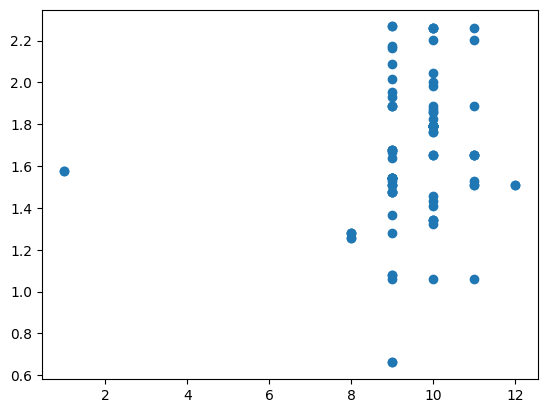

In [5]:
plt.scatter(new_df['Month'],new_df['Price per kg'])# not useful use another chart
plt.show()

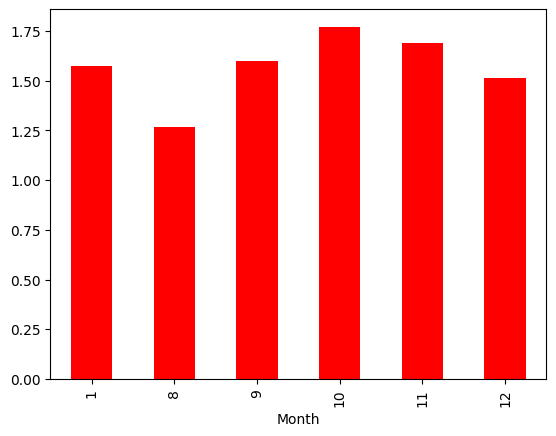

In [6]:
new_df.groupby('Month')['Price per kg'].mean().plot(kind='bar',color='red')
plt.show()


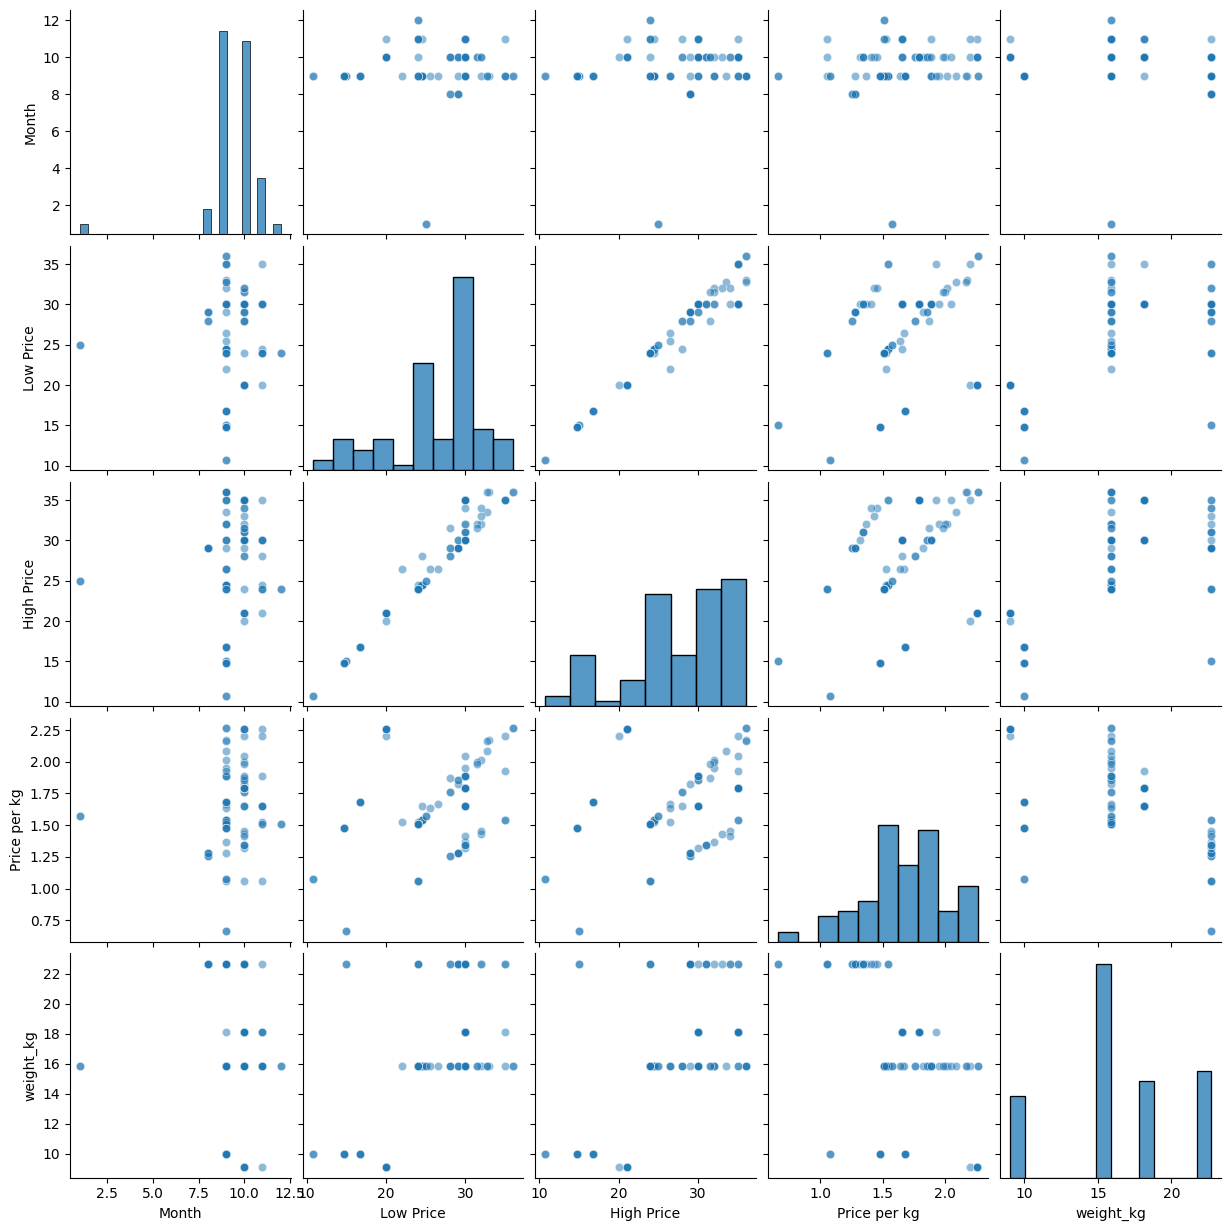

In [7]:
sns.pairplot(new_df,kind='scatter',plot_kws={'alpha':0.5})
plt.show()

In [8]:
new_df.corr(numeric_only=True) #if closer to 1,-1 good for lr

,Month,Low Price,High Price,Price per kg,weight_kg
Month,1.000000,0.096958,0.132352,0.153307,-0.009471
Low Price,0.096958,1.000000,0.964217,0.355785,0.582195
High Price,0.132352,0.964217,1.000000,0.381227,0.556465
Price per kg,0.153307,0.355785,0.381227,1.000000,-0.509999
weight_kg,-0.009471,0.582195,0.556465,-0.509999,1.000000


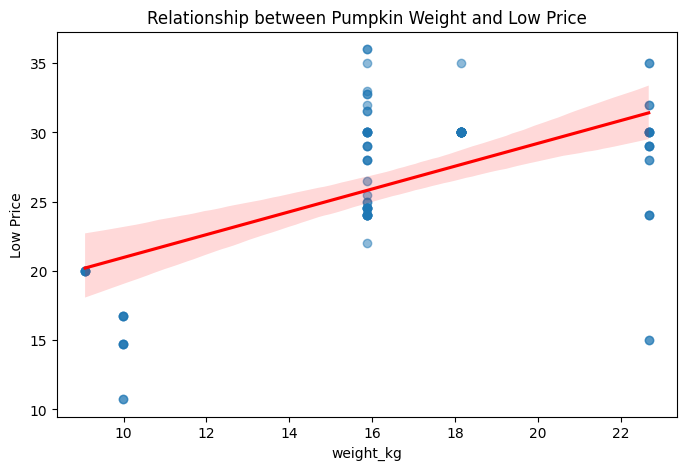

In [9]:
plt.figure(figsize=(8, 5))
# regplot plots the dots and the linear regression line
sns.regplot(x='weight_kg', y='Low Price', data=new_df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
#sns.regplot() is Seaborn's specialized tool for drawing a regression plot. It is incredibly useful because it combines two steps into one: it creates a scatter plot of your data and calculates and draws the linear regression model right on top of it.
plt.title('Relationship between Pumpkin Weight and Low Price')
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [11]:
x=new_df[['Month','weight_kg']]
X=x
y=new_df['Low Price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
lr=LinearRegression()
lr.fit(X_train,y_train)
pred=lr.predict(X_test)
score=lr.score(X_test,y_test)
print(score)

0.5727307668723767


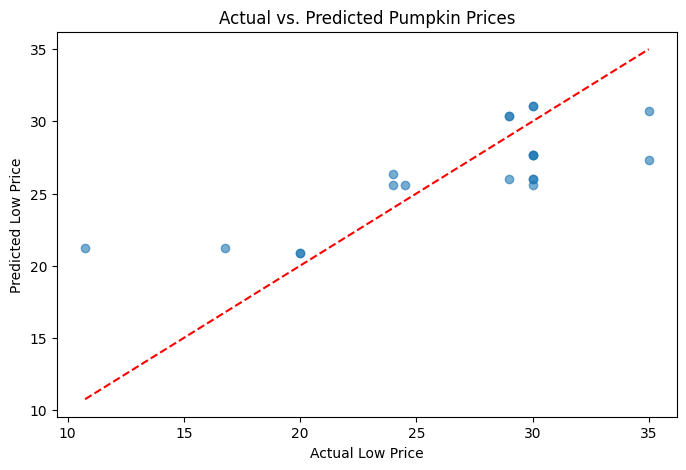

In [13]:
plt.figure(figsize=(8, 5))

# Plot Actual Prices (y_test) on the X-axis and Predicted Prices (pred) on the Y-axis
plt.scatter(x=y_test, y=pred, alpha=0.6)

# Draw a reference line for a "perfect" prediction
# (Where the actual price exactly matches the predicted price)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.xlabel('Actual Low Price')
plt.ylabel('Predicted Low Price')
plt.title('Actual vs. Predicted Pumpkin Prices')

plt.show()

In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())

pipeline.fit(X_train,y_train)
#Scikit-learn includes a helpful pipeline API to combine different steps of data processing together. A pipeline is a chain of estimators.
# In our case, we will create a pipeline that first adds polynomial features to our model, and then trains the regression:

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [17]:
pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,pred))
print(f'RMSE: {rmse:3.3} ({rmse/np.mean(pred)*100:3.3}%)')

score = pipeline.score(X_train,y_train)
print('Model determination: ', score)

RMSE: 3.46 (13.3%)
Model determination:  0.5446194406556116


In [18]:
X_range = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1,1)
y_range = pipeline.predict(X_range)

plt.scatter(X_test, y_test)
plt.plot(X_range, y_range)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


ValueError: X has 1 features, but PolynomialFeatures is expecting 2 features as input.